In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import scienceplots
import os
import glob
import os
import torch
import pickle
import numpy as np
import json
import matplotlib.pyplot as plt
import warnings
import pandas as pd
from math import floor, log10
from tensorboard.backend.event_processing import event_accumulator
import warnings
warnings.filterwarnings("ignore")
plt.style.use(['science','no-latex'])
import matplotlib.pylab as pylab
params = {'figure.dpi': 600,
            'axes.labelsize': 'small',
          'legend.fontsize': 'x-small',
         'axes.titlesize':'medium',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'font.family': 'DejaVu Sans'}
from matplotlib import rc
pylab.rcParams.update(params)

ORANGE = '#ffad33'
PINK = "#FF81C0"
MAGENTA = "#FF00FF"
YELLOW = "#FAC205"
SILVER = "#C5C9C7"
GRAY = "#929591"
DARK_GRAY = "#5b5b5b"
BLUE = "#069AF3"
DARK_BLUE = "#0000FF"
RBLUE = "#0088cc" #"#2d72ed"
RPURPLE = "#5c12de"
RYELLOW = "#dead12"
GREEN = "#56BE25"

# Best experiments we are plotting in the paper
protein_to_best_diffusion_exp = {
    "chignolin": "test_initial_latent_time=250",
    "bba": "test_initial_latent_time_250_hutch_minus_SGD_32paths",
    "trp_cage": "test_initial_latent_time=250",
    "villin": "test_initial_latent_time=250_lt10_truncated_sgd_dt1",
    "protein_g": "test_initial_latent_time=250_lt10_truncated_sgd_dt0.1"
}

protein_to_best_flowmatching_exp = {
  "chignolin": "",
  "bba": "test_sgd_initial_guess_level=7_dt=0.05_repr_flowmatching",
  "trp_cage": "test_sgd_initial_guess_level=7_dt=0.05_flowmatching",
  "villin": "",
  "protein_g": "",
}


def make_tetrapeptide_figures(names, results_dir, split, figure_name, errorbar=False, plot_reference=False):
  rep_names = ["100ns", "50ns", "30ns", "20ns", "10ns", "5ns", "2ns"]
  proteins = pd.read_csv(split, index_col="name").index
  jsds = {}
  valid_path_rates = {}
  path_probs = {}
  for i, name in enumerate(names):
      full_path = os.path.join(results_dir, f"main_eval_output_{name}")
      
      for protein in proteins:
        try:
          # protein_path = os.path.join(full_path, protein)
          # data = pickle.load(open(os.path.join(protein_path, f"{protein}.pkl"), "rb"))
          try:
            data = pickle.load(open(os.path.join(full_path, f"{protein}.pkl"), "rb"))
          except:
            print(f"Could not load {protein}")
            continue
          if i == 0: # only have to go through replicates once
            for rep_name in rep_names:
              if rep_name in jsds.keys():
                jsds[rep_name].append(data[f"{rep_name}_rep_JSD"])
              else:
                jsds[rep_name] = [data[f"{rep_name}_rep_JSD"]]

              if rep_name in valid_path_rates.keys():
                valid_path_rates[rep_name].append(data[f"{rep_name}_rep_valid_rate"])
              else:
                valid_path_rates[rep_name] = [data[f"{rep_name}_rep_valid_rate"]]

              if rep_name in path_probs.keys():
                path_probs[rep_name].append(data[f"{rep_name}_rep_valid_log_prob"].item())
              else:
                path_probs[rep_name] = [data[f"{rep_name}_rep_valid_log_prob"].item()]

            # Now get the reference path probabilities
            if "Reference" in path_probs.keys():
                path_probs["Reference"].append(data[f"ref_log_prob"])
            else:
              path_probs["Reference"] = [data[f"ref_log_prob"]]


          # Now get data for the method
          if name in jsds.keys():
            jsds[name].append(data["gen_JSD"])
          else:
            jsds[name] = [data["gen_JSD"]]

          if name in valid_path_rates.keys():
            valid_path_rates[name].append(data["gen_valid_rate"])
          else:
            valid_path_rates[name] = [data["gen_valid_rate"]]
          
          if name in path_probs.keys():
            path_probs[name].append(data["gen_valid_log_prob"])
          else:
            path_probs[name] = [data["gen_valid_log_prob"]]
        except:
          print(f"Could not evaluate {protein}")
  # Average across proteins
  array_of_path_probs = {}
  for key in jsds.keys():
    jsds[key] = np.array(jsds[key]).mean()
    valid_path_rates[key] = np.array(valid_path_rates[key]).mean()
    array_of_path_probs[key] = np.array(path_probs[key])
    path_probs[key] = np.array(path_probs[key]).mean() 
  
  path_probs["Reference"] = np.array(path_probs["Reference"]).mean() 
  
    
  # path_probs[key] = np.nan_to_num(np.array(path_probs[key]), nan=0.0).mean() 

  # Combine data into a structure for grouped plotting
  # Prepare data
  methods = names + ["Reference"] + rep_names if plot_reference else names + rep_names
  metrics = ['Jensen \n Shannon \n Divergence (↓)', 'Valid Transition \n Path Rate (↑)', 'Average Transition \n Negative Log Likelihood (↓)']  
  data = [
        jsds,
        valid_path_rates,
        path_probs,
    ]

  # Define colors
  colors = {
      "100ns": "#ADD8E6",  # Light blue
      "50ns": "#87CEEB",  # Sky blue
      "30ns": "#4682B4",  # Steel blue
      "20ns": "#4169E1",  # Royal blue
      "10ns": "#0000CD",  # Medium blue
      "5ns": "#00008B",   # Dark blue
      "2ns": "#000080"    # Navy blue
  }

  other_colors = [ORANGE, MAGENTA, SILVER, RPURPLE, GREEN, DARK_GRAY]


  # Set up bar positions
  bar_width = 0.1
  n_metrics = len(metrics)
  n_methods = len(methods)
  x = np.arange(n_metrics)

  # Initialize figure and axes
  fig, ax1 = plt.subplots(figsize=(8, 6))
  ax2 = ax1.twinx()  # Secondary y-axis for average path probability

  print(methods)
  for i, method in enumerate(methods):
      if method in colors.keys():
        color = colors[method]
      elif method == "Reference":
        color = GREEN
      else:
        color = other_colors.pop(0)
      # Plot JSD and Valid Path Rate (left y-axis)
      if "ns" in method:
        label = method + " MD"
      elif "Reference" in method:
        label = "Reference Simulations"
      elif "flowmatching" in method:
        label = "OM Interpolation - Flow Matching Model"
      else:
        label = "OM Interpolation - \nDiffusion Model"

      if method == "Reference":
        data[0][method] = 0 # JSD
        data[1][method] = 1 # Valid Path rate
      ax1.bar(x[0] + i * bar_width*0.4, data[0][method] + 1e-2, bar_width, label=label, color=color, yerr=None, capsize=3)
      ax1.bar(x[1] + i * bar_width*0.4, data[1][method]+ 1e-2, bar_width, color=color, yerr=None, capsize=3)
      # Plot Average Path Probability (right y-axis)
      ax2.bar(x[2] + i * bar_width*0.4, - data[2][method], bar_width, color=color, yerr=None, capsize=3)

  # Add a vertical dotted line between Valid Path Rate and Average Path Probability
  ax1.axvline(x=1.65, color='gray', linestyle='dotted', linewidth=2)

  # Customize axes
  # ax1.set_xlabel("Metrics", fontsize=12)
  ax1.set_ylabel("JSD & Valid Path Rate", fontsize=16)
  ax2.set_ylabel("Negative Log Likelihood", fontsize=16)
  ax1.set_xticks(x + (n_methods - 1) * bar_width / 2)
  custom_positions = [0.15, 1.15, 2.1]  # Centered positions for 'JSD', 'Valid Path Rate', 'Average Path Probability'
  ax1.set_xticks(custom_positions)
  ax1.set_xticklabels(metrics, fontsize=14)
  # ax1.legend(fontsize=10, loc="upper left")

  # Title and layout
  # plt.title("Performance Comparison of Methods by Metrics", fontsize=14)
  plt.tight_layout()
  plt.savefig(f"{figure_name}.png")
  plt.show()

  fig_legend = plt.figure(figsize=(8, 1.2))
  handles, labels = ax1.get_legend_handles_labels()
  fig_legend.legend(
      handles,
      labels,
      loc='center',
      ncol=3,
      frameon=True,         # <-- Adds the box around the legend
      fontsize=12,
      borderaxespad=0.3,
      edgecolor='black'     # Optional: explicitly set box edge color
  )

  # Remove margins and save legend figure
  fig_legend.tight_layout()
  fig_legend.savefig(f"{figure_name}_legend.png", bbox_inches='tight', dpi=300)
  plt.close(fig_legend)
  return {name: array_of_path_probs[name] for name in names}, proteins
      

Could not load HTIQ
Could not load ESSS
Could not load VIYH
Could not load SPVN
Could not load MIAY
Could not load TLRK
Could not load LVVF
Could not load WQVP
Could not load EDQK
Could not load CACS
Could not load IHNV
Could not load SPFH
Could not load FSRK
Could not load QNWV
Could not load LIFE
Could not load ALDA
Could not load GCIC
Could not load RDWY
Could not load ESIC
Could not load LIRH
Could not load CIYL
Could not load DHAR
Could not load IDRH
['om_interpolate_test_april14_model_fulldataset_dt=0.0001_actualendpoints_500steps_flowmatching', '100ns', '50ns', '30ns', '20ns', '10ns', '5ns', '2ns']


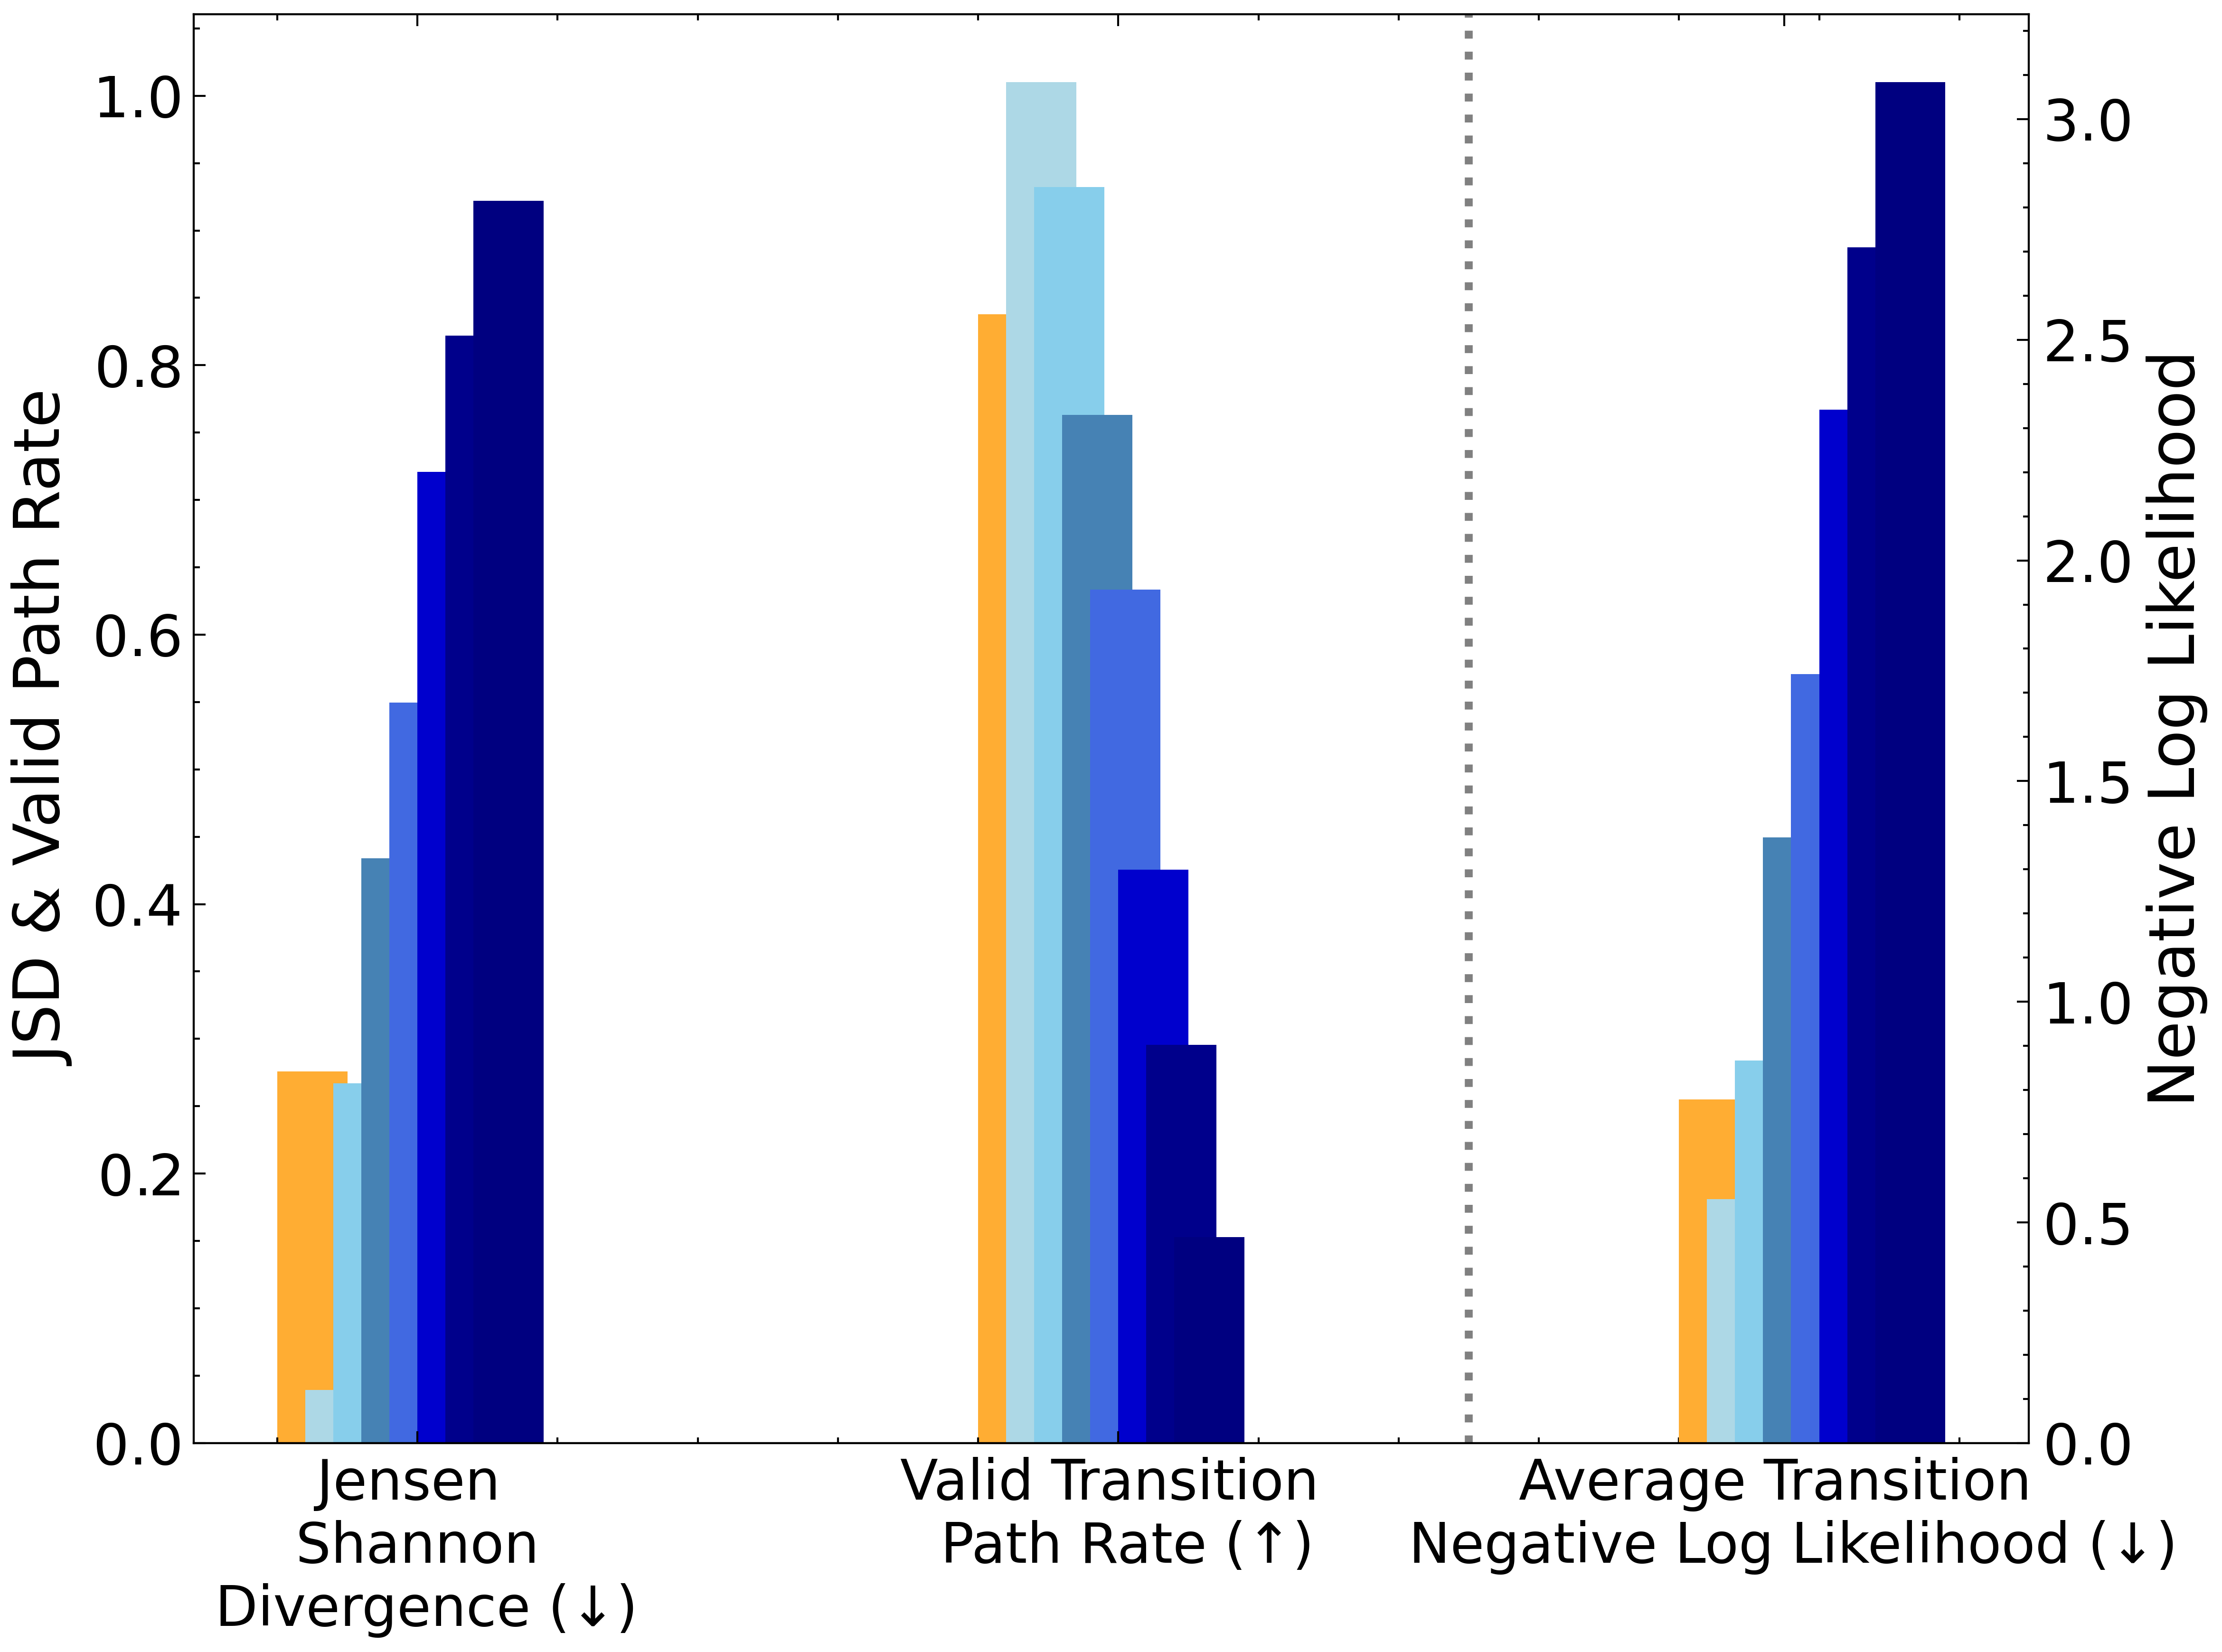

In [2]:
names = ['om_interpolate_test_april14_model_fulldataset_dt=0.0001_actualendpoints_500steps_flowmatching']#, 'om_interpolate_initial_guess_level=7_latent_time=0.5_flowmatching']
# names = ['om_interpolate_initial_guess_level=7_latent_time=0.5_flowmatching']

results_dir = 'saved_models/tetrapeptides_all_atom'
split = "mdgen/splits/4AA_test.csv"
array_of_path_probs, proteins = make_tetrapeptide_figures(names, results_dir, split, "tetra_all_atom_figure_ALL", plot_reference = False)

In [56]:
idxs = np.argsort(array_of_path_probs["om_interpolate_test_april14_model_fulldataset_dt=0.0001_flowmatching"])
proteins_sorted = [proteins[i] for i in idxs]
proteins_sorted

['KAQW',
 'SPFH',
 'DLCG',
 'IPTH',
 'PIDV',
 'VDRN',
 'HTIQ',
 'SPVN',
 'LAWA',
 'FSRK',
 'SDFS',
 'FGGW',
 'HELI',
 'YCPF',
 'NVFH',
 'AGVD',
 'CKVH',
 'IWHF',
 'SSNN',
 'FSDP',
 'INVH',
 'LCLQ',
 'LIFE',
 'LWMR',
 'IPGD',
 'GLIL',
 'IAMI',
 'LQMG',
 'KSIY',
 'YMQN',
 'ALDA',
 'KDDD',
 'DQKV',
 'KAEP',
 'RTVD',
 'SFCH',
 'QNWV',
 'FLRH',
 'SNSF',
 'PRVC',
 'NTVG',
 'EDQK',
 'ESSS',
 'VIYH',
 'ASRE',
 'GGHN',
 'WWQW',
 'KEGH',
 'QVTC',
 'IHNV',
 'QRNF',
 'RVQS',
 'WSAQ',
 'RDWY',
 'CPYV',
 'FDNT',
 'SNIN',
 'MWQK',
 'CPEE',
 'GCIC',
 'LVVF',
 'KDFM',
 'NWWG',
 'NFQF',
 'PKDM',
 'TLRK',
 'RVQQ',
 'RLKR',
 'NNDK',
 'VWVR',
 'VQCL',
 'AKIR',
 'FHSE',
 'MIAY',
 'PYHQ',
 'YLID',
 'CACS',
 'IMRY',
 'PGKM',
 'IVMA',
 'WQVP',
 'CSYR',
 'APWF',
 'MHVR',
 'FKKL',
 'CKHT',
 'YQGI']

In [10]:
protein_name_dict = {
    "bba": "BBA",
    "trp_cage": "Trp-cage",
    "chignolin": "Chignolin",
    "villin": "Villin",
    "protein_g": "Protein G",
}

def make_transition_rate_figure(names, results_dir, time_per_iteration, figure_name):
    for i, name in enumerate(names):
        if "om" in name:
            full_path = os.path.join(results_dir, f"main_eval_output_{name}")
            transition_rates = np.load(os.path.join(full_path, "mean_transition_rates.npy"))
            means = transition_rates.mean(axis=-1) # Average across paths
            stds = transition_rates.std(axis=-1) # Standard deviation across paths
            x_axis = np.linspace(time_per_iteration, time_per_iteration * len(means), len(means))
            label = "OM Interpolation"
        elif "iid" in name:
            means = [0.32, 0.35, 0.37, 0.36]
            x_axis = [247 * 0.001, 247 * 0.01, 247 * 0.1, 247]
            label = "I.I.D Sampling"
        elif "langevin" in name:
            means = [0.13, 0.13, 0.13, 0.15, 0.16]
            x_axis = [1062 / 10, 1062 / 5, 1062 / 2, 1062/1.2, 1062]
            label = "Langevin Dynamics"

        
        plt.plot(x_axis, means, label=label)
        plt.xlabel("Wall Clock Time (GPU-Minutes)")
        plt.ylabel(r"$\frac{\text{Transition Rate}}{k_B \mathcal{T}}$")
        plt.legend(loc="center right", frameon=True)
        plt.xscale("log")
        plt.savefig(f"{figure_name}.png")

def make_path_committor_figure(proteins, results_dir, figure_name):
    for i, protein in enumerate(proteins):
        name = protein_to_best_diffusion_exp[protein]
        full_path = os.path.join(results_dir, protein, f"main_eval_output_om_interpolate_{name}")
        path_committor_probs = np.load(os.path.join(full_path, "path_committor_probs.npy"))
        means = path_committor_probs.mean(axis=0)
        stds = path_committor_probs.std(axis=0)
        plt.plot(means, label=protein_name_dict[protein])
    
    plt.ylim(-0.1, 1.1)
    plt.xlabel("Path Step")
    plt.ylabel("Committor Probability")
    
    # Add horizontal lines
    plt.axhline(0, color="blue", linestyle="--")
    plt.axhline(1, color="red", linestyle="--")
    
    # Add labels on the lines
    # plt.text(100, 0.05, "Starting State", color="blue", ha="center", va="bottom")
    # plt.text(50, 1.07, "Ending State", color="red", ha="center", va="top")
    
    # make legend with box
    plt.legend(loc="center right", frameon=True, fontsize=6)
    plt.savefig(f"{figure_name}.png")
    plt.show()

               
            

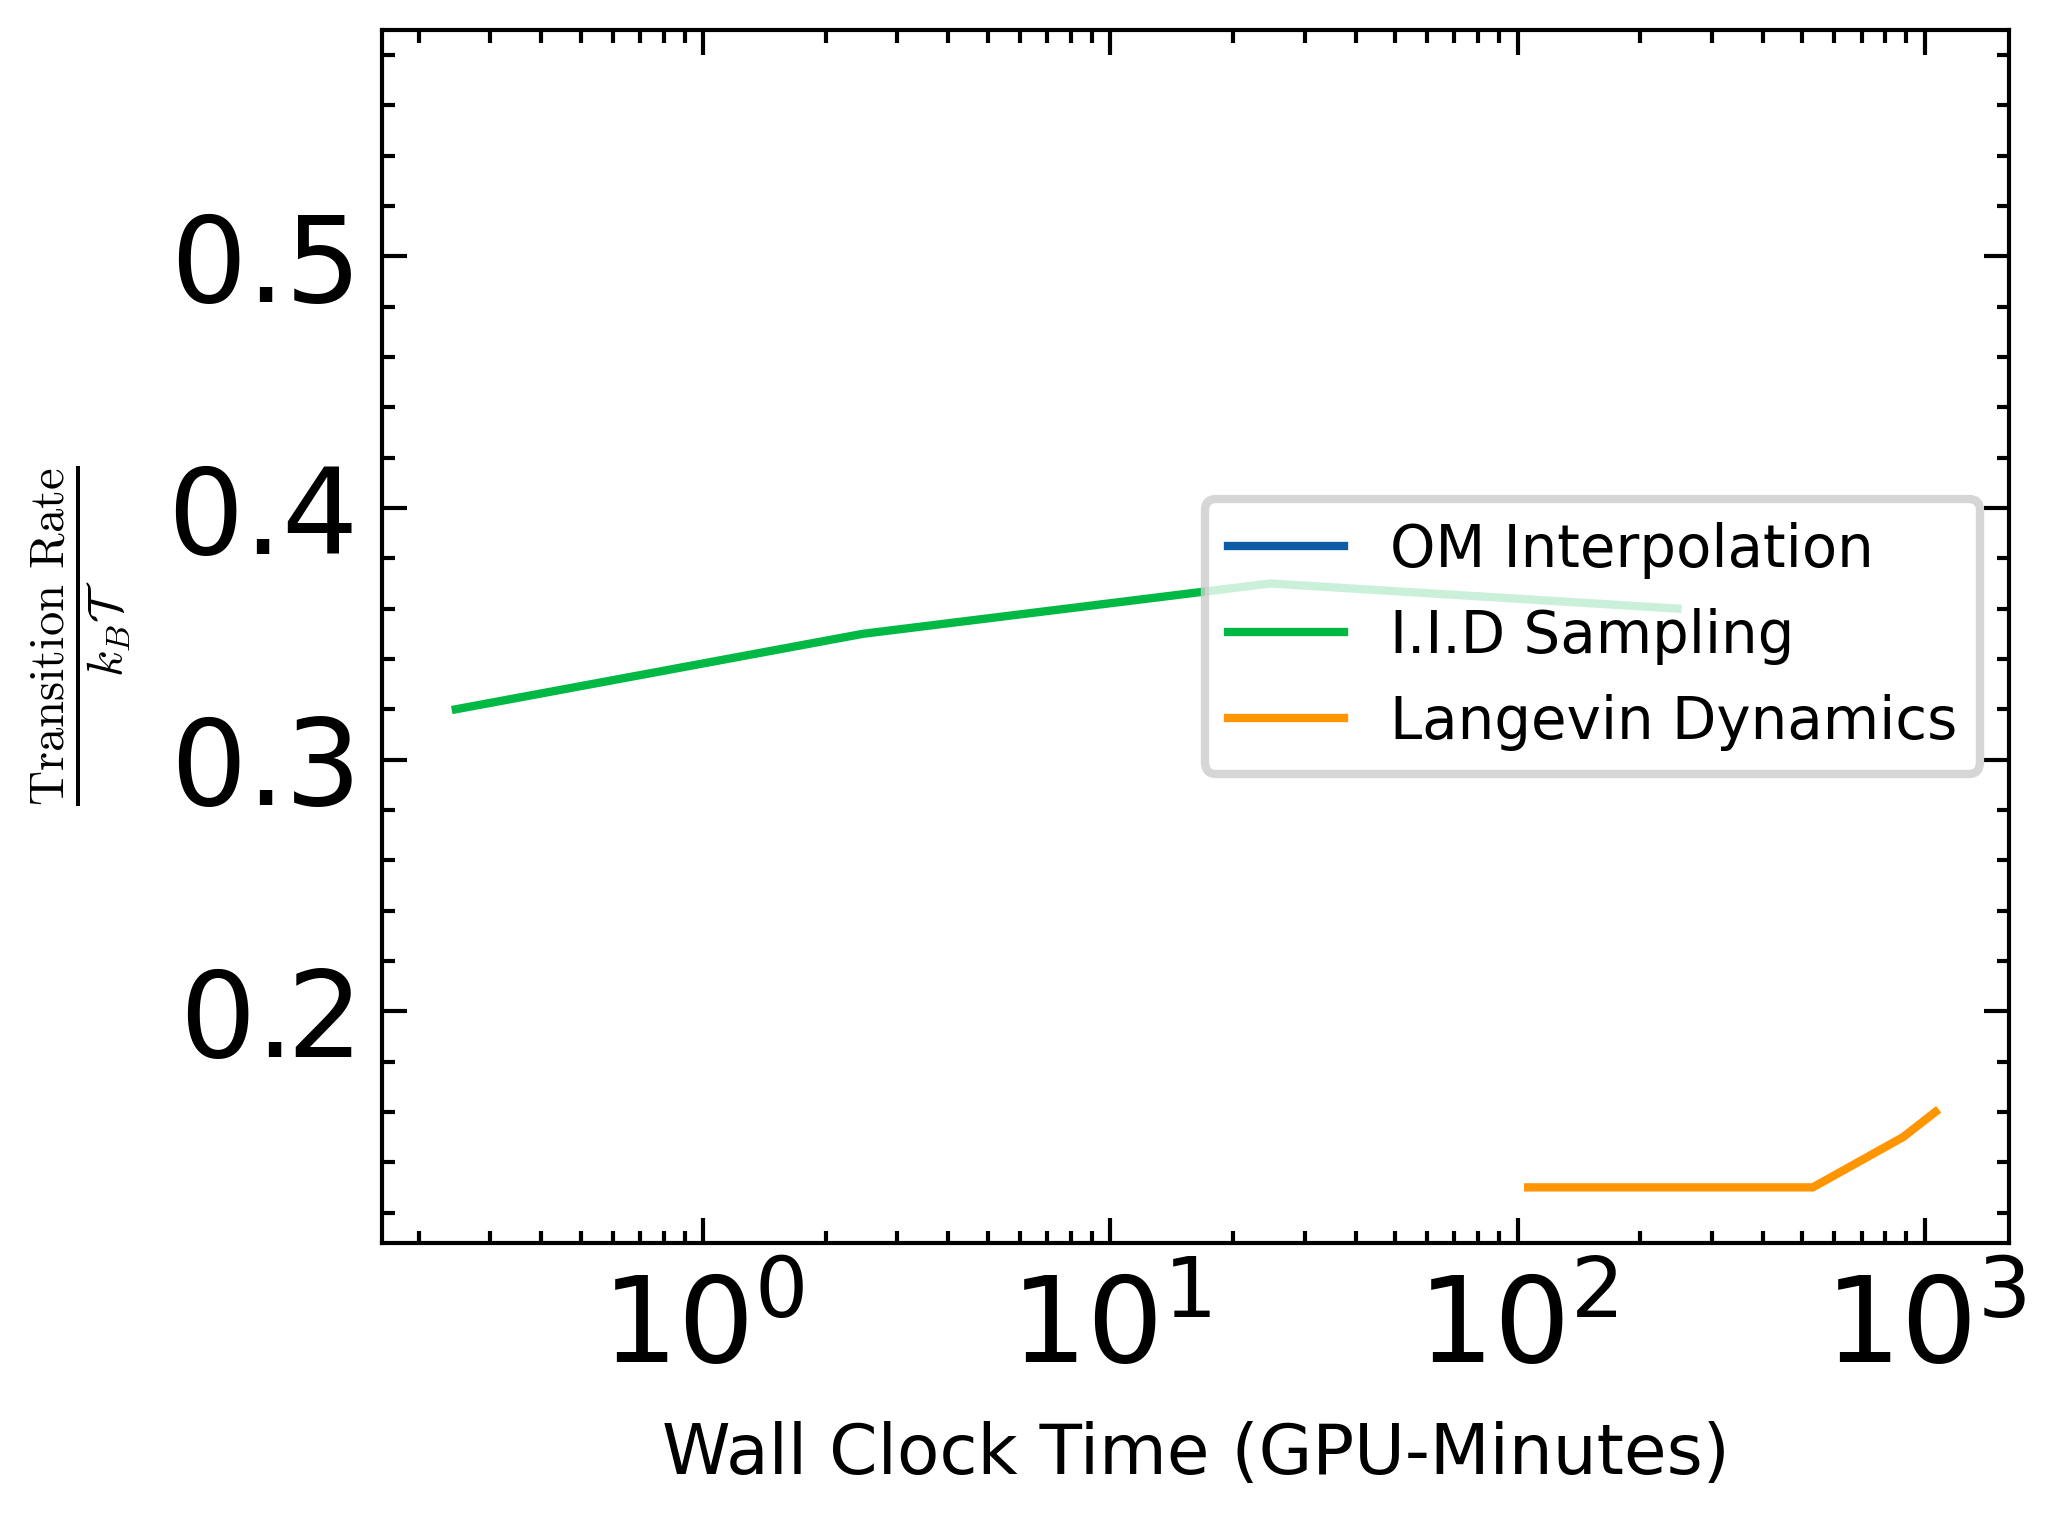

In [11]:
# names = ['om_interpolate_test_initial_latent_time_250_hutch_minus_SGD', 'om_interpolate_test_initial_latent_time=250_SGD', 'om_interpolate_test_initial_latent_time=250']
proteins = ["bba", "chignolin", "trp_cage", "villin", "protein_g"]
names = ['om_interpolate_test_initial_latent_time_250_hutch_minus_SGD', 'iid', 'langevin']
results_dir = 'saved_models/bba'
spacing = 20
total_time_mins = 37.12
total_steps = 1000
time_per_iteration = total_time_mins / total_steps * spacing
make_transition_rate_figure(names, results_dir, time_per_iteration, "bba_transition_rate_figure")
# make_path_committor_figure(proteins, results_dir, "committor_figure")



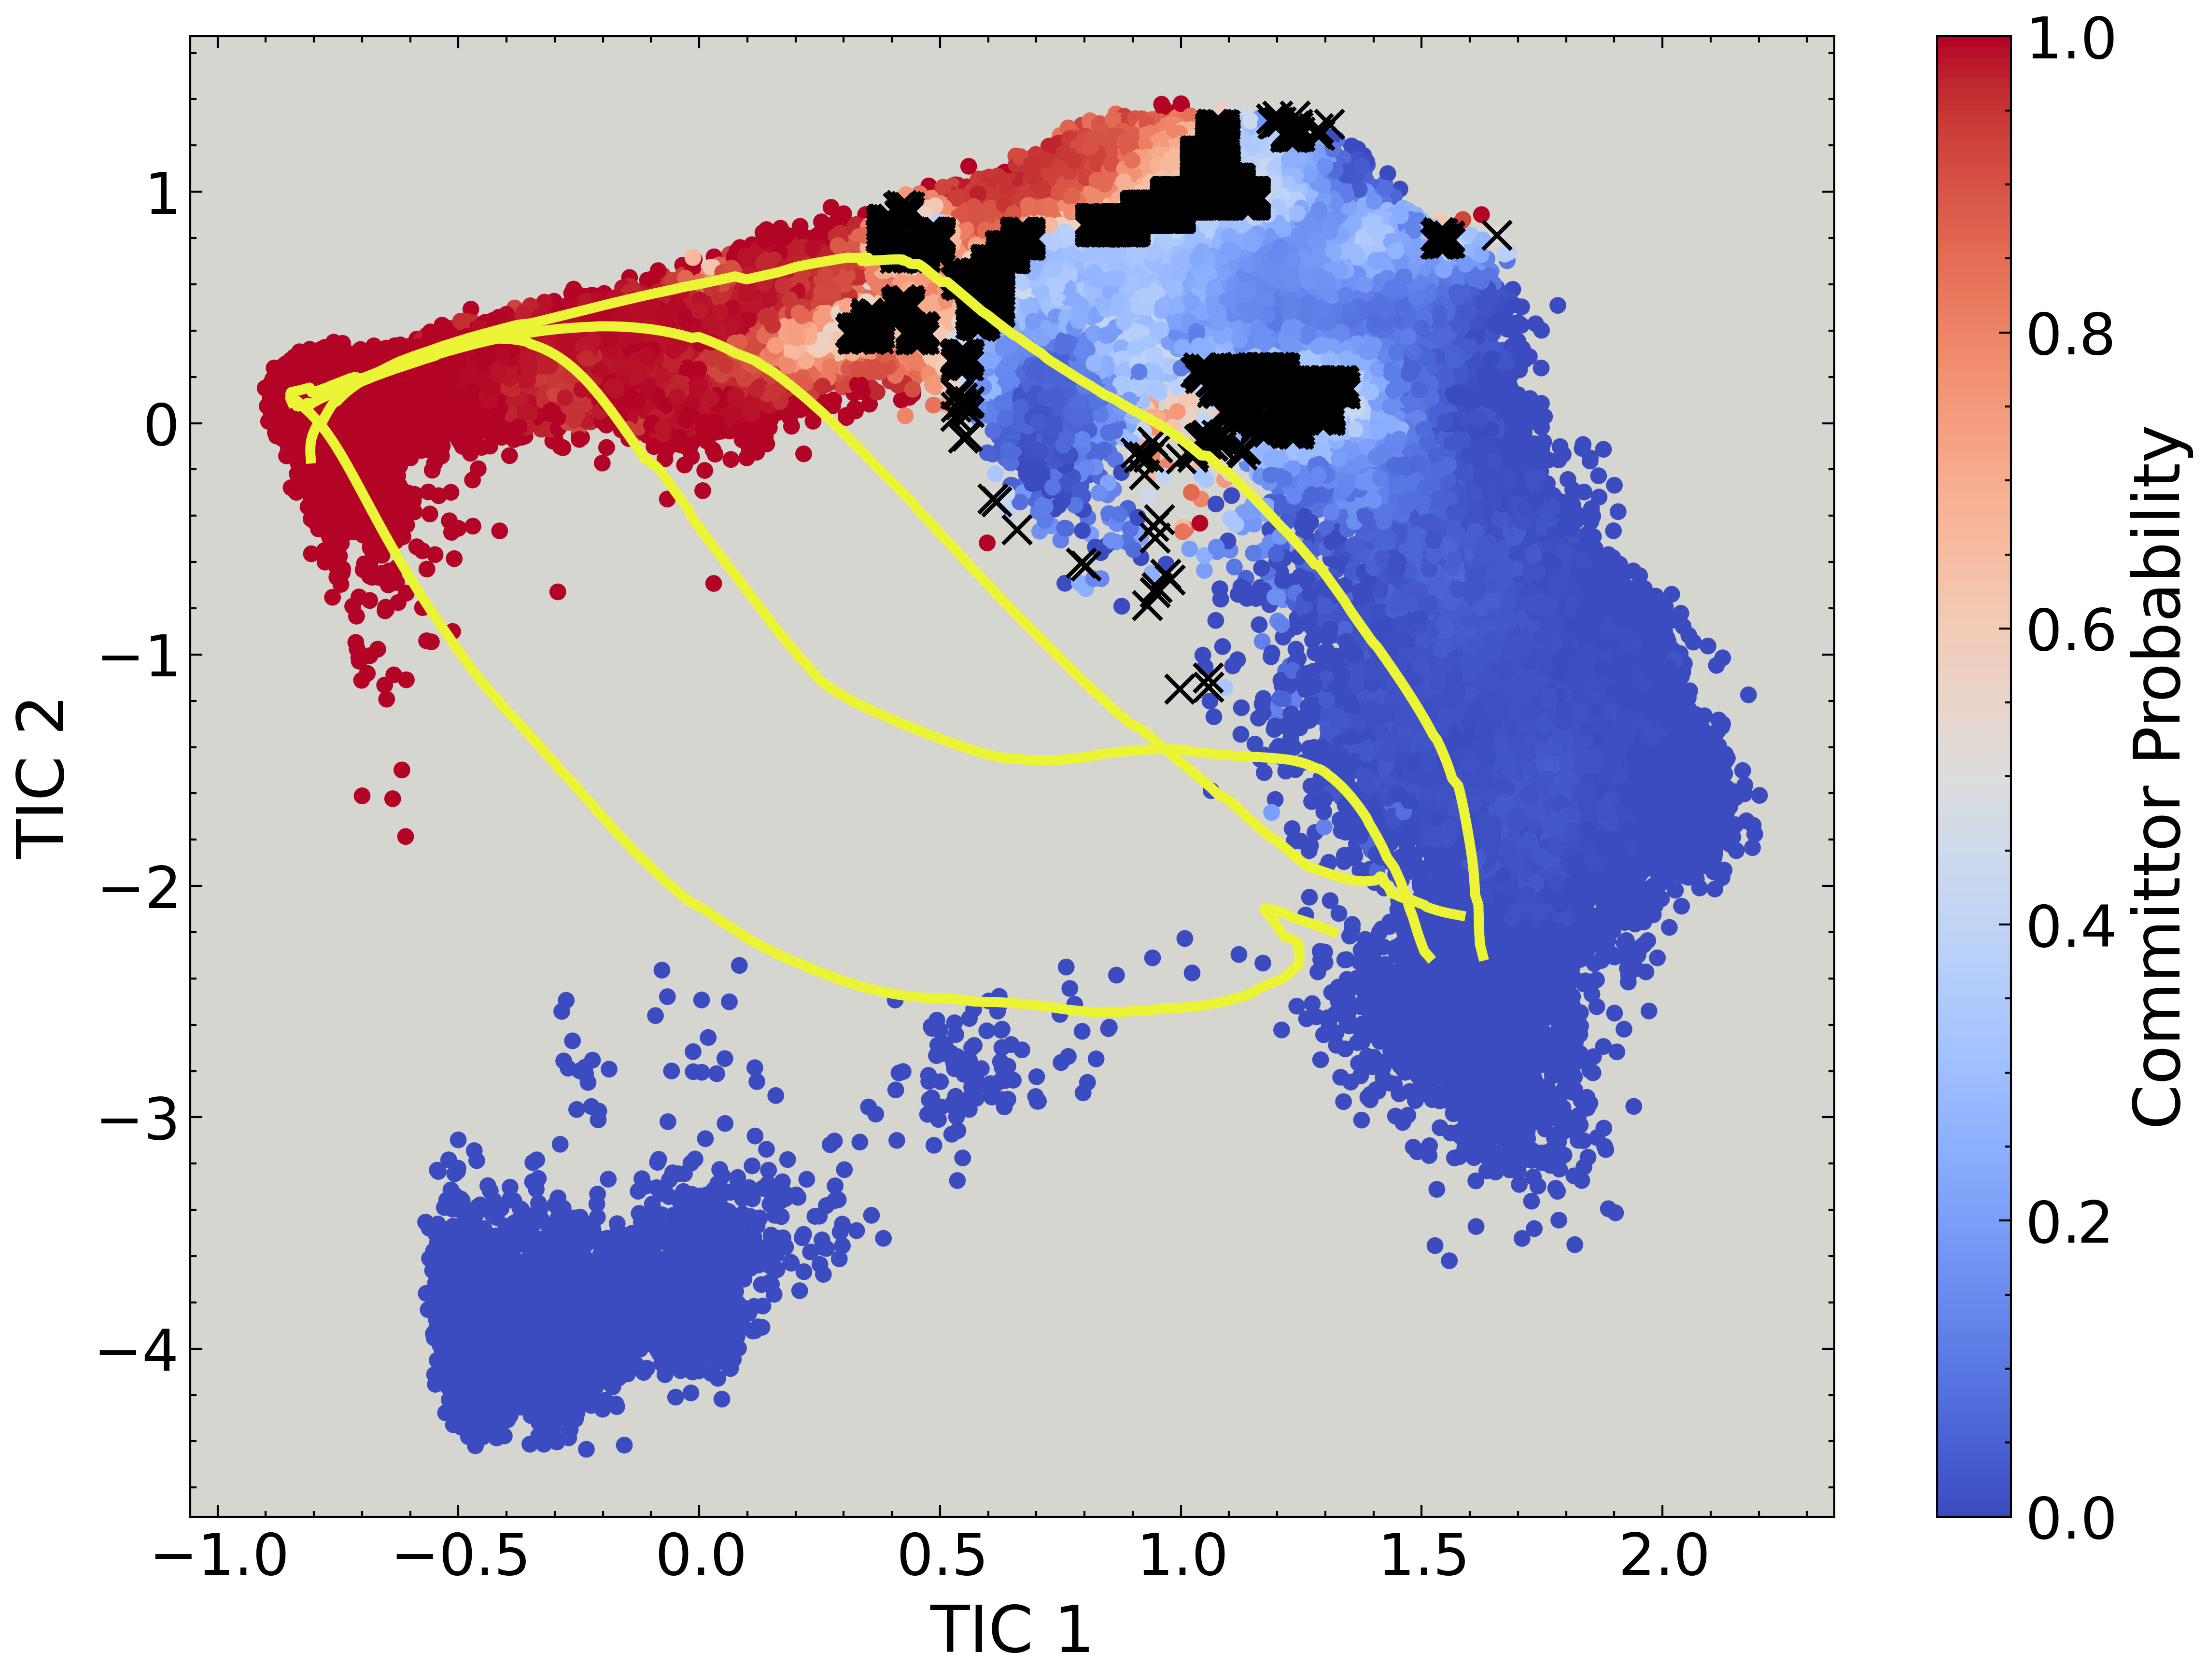

In [30]:
# Committor figures

protein_name = "protein_g"
gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = protein_to_best_diffusion_exp[protein_name] # Append string to the experiment name"


import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Function to generate slightly varied shades of a base color
def vary_color(base_color, factor, i):
    rgb = mcolors.hex2color(base_color)
    varied_rgb = [(min(1, max(0, channel + factor * (i - 4) / 10))) for channel in rgb]  # Adjust shade
    return mcolors.to_hex(varied_rgb)

device = torch.device(torch.cuda.current_device())


append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

# min-flux endpoints (not using for now)
cluster_endpoints_path = Path(
        os.path.join(
            "evaluate",
            "saved_references",
            f"saved_cluster_endpoints_{protein_name.upper()}.npy",
        )
    )

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

# Load samples from the ground truth simulations to serve as training data
dataset = DEShawDataset(
    data_root="/data/sanjeevr/Reference_MD_Sims",
    molecule=Molecules[protein_name.upper()],
    simulation_id=0,
    atom_selection=AtomSelection.A_CARBON,
    return_bond_graph=False,
    transform=to_angstrom,
    align=False,
)

gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

n_atoms = gt_traj.shape[1]

# Load topology from pdb file
topology = md.load(pdb_file).topology

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="datasets",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign cluster centers to the reference samples
if not os.path.exists(f"./evaluate/saved_references/saved_cluster_assignments_{protein_name.upper()}.npy"):
    cluster_assignments, transformed_samples = discretize_trajectory(
        gt_traj, tic_evaluator, cluster_coords
    )
    np.save(f"./evaluate/saved_references/saved_cluster_assignments_{protein_name.upper()}.npy", cluster_assignments)
    np.save(f"./evaluate/saved_references/saved_tic_samples_{protein_name.upper()}.npy", transformed_samples)
else:
    cluster_assignments = np.load(f"./evaluate/saved_references/saved_cluster_assignments_{protein_name.upper()}.npy")
    transformed_samples = np.load(f"./evaluate/saved_references/saved_tic_samples_{protein_name.upper()}.npy")

cluster_assignments = torch.tensor(cluster_assignments)

def get_gt_committor_probs(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y

    if os.path.exists(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy"):
        committor_probs = np.load(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy")
        return committor_probs[bin_idx]
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(tic.bins ** 2)
    bin_counts = torch.zeros(tic.bins ** 2)
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for i in tqdm(range(n_samples)):
        bin_counts[bin_idx[i]] += 1
        if last_transition_idx is not None and i <= last_transition_idx:
            # If we already determined the committor for the intermediate steps, assign and skip
            committor_probs[bin_idx[i]] += last_committor
        else:
            if is_start[i]:
                committor_probs[bin_idx[i]] += 0
                last_committor = 0
                last_transition_idx = i
            elif is_end[i]:
                committor_probs[bin_idx[i]] += 1
                last_committor = 1
                last_transition_idx = i
            else:
                # Search forward in the trajectory to find the next transition
                subsequent_clusters = clusters[i:]
                first_start = np.argmax(subsequent_clusters == start_cluster)
                first_end = np.argmax(subsequent_clusters == end_cluster)

                if (first_end == 0 or first_start > 0 and first_start < first_end):
                    last_committor = 0
                    last_transition_idx = i + first_start
                elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                    last_committor = 1
                    last_transition_idx = i + first_end
                else:
                    raise RuntimeError(f"No transition found for sample {i}")
                
                # Assign committor for current step
                committor_probs[bin_idx[i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    np.save(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy", committor_probs)
    
    return committor_probs[bin_idx]


start, end = CLUSTER_ENDPOINTS[protein_name]
probs = get_gt_committor_probs(transformed_samples, start, end, cluster_assignments, tic_evaluator)
probs = torch.tensor(probs)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(8, 6))

# First plot: Ground Truth Committor Probabilities
scatter1 = plt.scatter(transformed_samples[::10, 0], transformed_samples[::10, 1], c=probs[::10], cmap='coolwarm', s=10, alpha=1.0)
# Customize the background
ax = plt.gca()  # Get the current axis
ax.set_facecolor('#d5d6d0')  # Set the background color to gray
plt.xlabel("TIC 1", fontsize=16)
plt.ylabel("TIC 2", fontsize=16)
# plt.scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
# plt.scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
cbar = plt.colorbar(scatter1, label='Committor Probability')
cbar.set_label('Committor Probability', fontsize=16)

# Now plot the sampled path on top of this
sample_path = Path(eval_folder, f"sample-{gen_mode}.pt")
# Load sampled molecules
sampled_mol = torch.load(sample_path)
# Get TICA coordinates for the sampled molecules
_, transformed_mol = discretize_trajectory(sampled_mol, tic_evaluator, cluster_coords)
transformed_mol = transformed_mol.reshape(-1, 200, 2)
num_paths = transformed_mol.shape[0]
rng = range(20, 32) if protein_name == "bba" else range(num_paths)
for i in rng:
    # plot path
    color = "#ecf535"
    # plt.plot(
    #     transformed_mol[i, :, 0],
    #     transformed_mol[i, :, 1],
    #     c='black',  # Black border
    #     alpha=1,
    #     linewidth=5.5,  # Slightly thicker for the border
    # )
    plt.plot(transformed_mol[i, :, 0], transformed_mol[i, :, 1], c=color, alpha=1, linewidth=2.5, label='Sampled Transition Paths' if i == 0 else None)
    # Plot endpoints with x's:
    # plt.scatter(transformed_mol[i, 0, 0], transformed_mol[i, 0, 1], c=color, s=400, marker='x')
    # plt.scatter(transformed_mol[i, -1, 0], transformed_mol[i, -1, 1], c=color, s=400, marker='x')

# Plot transition state ensemble
mask = (probs[::2] > 0.45) & (probs[::2] < 0.55)
# Save TICA coordinates for the transition state ensemble
transition_state_samples = transformed_samples[::2][mask]

# Encircle transition state samples
plt.scatter(
    transition_state_samples[:, 0], 
    transition_state_samples[:, 1], 
    marker = 'x',
    c = 'black',
    s=50, 
    alpha = 1.0,
    label='Transition State Ensemble'
)

# plt.legend(fontsize=16, frameon=True)
plt.tight_layout()
plt.savefig(f"./evaluate/saved_references/{protein_name}_{start}_{end}_committor_plots.png")
plt.show()





In [10]:

def make_fastfolder_msm_figures(proteins, results_dir, figure_name, errorbar=False):
  rep_names = ["1ns", "2ns", "4ns", "6ns", "8ns", "10ns", "12ns"][::-1]
  # TODO: write this function
  
  jsds = {}
  valid_path_rates = {}
  path_probs = {}
  for protein in proteins:
      
      
      langevin_path = os.path.join(results_dir, protein, f"main_eval_output_langevin")
      
      # Get data for the Langevin method (different replicates)
      for rep_name in rep_names:
        metrics = json.load(open(os.path.join(langevin_path, f"final_metrics_subsample_{rep_name}.json"), "r"))
        if rep_name in jsds.keys():
          jsds[rep_name].append(metrics["Jensen-Shannon Divergence of State Distributions"])
        else:
          jsds[rep_name] = [metrics["Jensen-Shannon Divergence of State Distributions"]]

        if rep_name in valid_path_rates.keys():
          valid_path_rates[rep_name].append(metrics["Fraction of Valid Paths"])
        else:
          valid_path_rates[rep_name] = [metrics["Fraction of Valid Paths"]]
        
        if rep_name in path_probs.keys():
          path_probs[rep_name].append(metrics["Path Probability Mean"])
        else:
          path_probs[rep_name] = [metrics["Path Probability Mean"]]
          
      
      # Now get data for the method (Both diffusion and flow matching)
      
      # Diffusion model
      exp_name_diffusion = "om_interpolate_" + protein_to_best_diffusion_exp[protein]
      full_path_diffusion = os.path.join(results_dir, protein, f"main_eval_output_{exp_name_diffusion}")
      metrics = json.load(open(os.path.join(full_path_diffusion, f"final_metrics.json"), "r"))
      if "OM Interpolation - \nDiffusion Model" in jsds.keys():
        jsds["OM Interpolation - \nDiffusion Model"].append(metrics["Jensen-Shannon Divergence of State Distributions"])
      else:
        jsds["OM Interpolation - \nDiffusion Model"] = [metrics["Jensen-Shannon Divergence of State Distributions"]]

      if "OM Interpolation - \nDiffusion Model" in valid_path_rates.keys():
          valid_path_rates["OM Interpolation - \nDiffusion Model"].append(metrics["Fraction of Valid Paths"])
      else:
        valid_path_rates["OM Interpolation - \nDiffusion Model"] = [metrics["Fraction of Valid Paths"]]
      
      if "OM Interpolation - \nDiffusion Model" in path_probs.keys():
        path_probs["OM Interpolation - \nDiffusion Model"].append(metrics["Path Probability Mean"])
      else:
        path_probs["OM Interpolation - \nDiffusion Model"] = [metrics["Path Probability Mean"]]


      # Flow matching model
      # exp_name_flow = "om_interpolate_" + protein_to_best_flow_exp[protein]
      # full_path_flow = os.path.join(results_dir, protein, f"main_eval_output_{exp_name_flow}")
      # metrics = json.load(open(os.path.join(full_path_flow, f"final_metrics.json"), "r"))
      # if "OM Interpolation - Flow Matching Model" in jsds.keys():
      #   jsds["OM Interpolation - Flow Matching Model"].append(metrics["Jensen-Shannon Divergence of State Distributions"])
      # else:
      #   jsds["OM Interpolation - Flow Matching Model"] = [metrics["Jensen-Shannon Divergence of State Distributions"]]

      # if "OM Interpolation - Flow Matching Model" in valid_path_rates.keys():
      #     valid_path_rates["OM Interpolation - Flow Matching Model"].append(metrics["Fraction of Valid Paths"])
      # else:
      #   valid_path_rates["OM Interpolation - Flow Matching Model"] = [metrics["Fraction of Valid Paths"]]
      
      # if "OM Interpolation - Flow Matching Model" in path_probs.keys():
      #   path_probs["OM Interpolation - Flow Matching Model"].append(metrics["Path Probability Mean"])
      # else:
      #   path_probs["OM Interpolation - Flow Matching Model"] = [metrics["Path Probability Mean"]]

        
  # Average across proteins
  for key in jsds.keys():
    jsds[key] = np.array(jsds[key]).mean()
    valid_path_rates[key] = np.array(valid_path_rates[key]).mean()
    path_probs[key] = np.array(path_probs[key]).mean() 

  # Calculate standard deviations
  jsds_std = {key: values.std() for key, values in jsds.items()}
  valid_path_rates_std = {key: values.std() for key, values in valid_path_rates.items()}
  path_probs_std = {key: values.std() for key, values in path_probs.items()}

  # Combine data into a structure for grouped plotting
  # Prepare data
  names = ["OM Interpolation - \nDiffusion Model"]
  # names = names + ["OM Interpolation - Flow Matching Model"]
  methods = names + rep_names
  metrics = ['Jensen \n Shannon \n Divergence (↓)', 'Valid Transition \n Path Rate (↑)', 'Average \n Transition \n Path Probability (↑)']  
  data = [
        jsds,
        valid_path_rates,
        path_probs,
    ]

  data_stds = [
    jsds_std,
    valid_path_rates_std,
    path_probs_std,
  ]

  # Define colors
  colors = {
      "12ns": "#ADD8E6",  # Light blue
      "10ns": "#87CEEB",  # Sky blue
      "8ns": "#4682B4",  # Steel blue
      "6ns": "#4169E1",  # Royal blue
      "4ns": "#0000CD",  # Medium blue
      "2ns": "#00008B",   # Dark blue
      "1ns": "#000080"    # Navy blue
  }

  other_colors = [ORANGE, MAGENTA, SILVER, RPURPLE, GREEN, DARK_GRAY]


  # Set up bar positions
  bar_width = 0.1
  n_metrics = len(metrics)
  n_methods = len(methods)
  x = np.arange(n_metrics)

  # Initialize figure and axes
  fig, ax1 = plt.subplots(figsize=(6, 6))
  ax2 = ax1.twinx()  # Secondary y-axis for average path probability

  print(methods)
  for i, method in enumerate(methods):
      if method in colors.keys():
          color = colors[method]
      else:
          color = other_colors.pop(0)
      # Plot JSD and Valid Path Rate (left y-axis)
      ax1.bar(x[0] + i * bar_width * 0.4, data[0][method] + 1e-2, bar_width, label=method + " MD" if "ns" in method else method, color=color, yerr=data_stds[0][method] if errorbar else None, capsize=3)
      ax1.bar(x[1] + i * bar_width * 0.4, data[1][method] + 1e-2, bar_width, color=color, yerr=data_stds[1][method] if errorbar else None, capsize=3)

      # Plot Average Path Probability (right y-axis)
      ax2.bar(x[2] + i * bar_width * 0.4, data[2][method] + 1e-3, bar_width, color=color, yerr=data_stds[2][method] if errorbar else None, capsize=3)

  # Add a vertical dotted line between Valid Path Rate and Average Path Probability
  ax1.axvline(x=1.65, color='gray', linestyle='dotted', linewidth=2)

  # Customize axes
  ax1.set_ylabel("JSD & Valid Path Rate", fontsize=14)
  ax2.set_ylabel("Average Path Probability", fontsize=14)
  custom_positions = [0.15, 1.15, 2.2]  # Centered positions for 'JSD', 'Valid Path Rate', 'Average Path Probability'
  ax1.set_xticks(custom_positions)
  ax1.set_xticklabels(metrics, fontsize=11)

  # Save the main plot without a legend
  # ax1.legend().remove()  # Remove the legend from the main plot
  plt.tight_layout()
  plt.savefig(f"{figure_name}.png", bbox_inches="tight")
  plt.show()

  # Create a separate figure for the legend
  legend_fig = plt.figure(figsize=(3, len(methods) * 0.5))  # Adjust height based on the number of methods
  handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from the main plot
  legend_fig.legend(
      handles,
      labels,
      loc="center",
      ncol=1,  # Stack vertically
      fontsize=16,
      frameon=True,
  )
  legend_fig.tight_layout()
  legend_fig.savefig(f"{figure_name}_legend.png", bbox_inches="tight")



['OM Interpolation - \nDiffusion Model', '12ns', '10ns', '8ns', '6ns', '4ns', '2ns', '1ns']


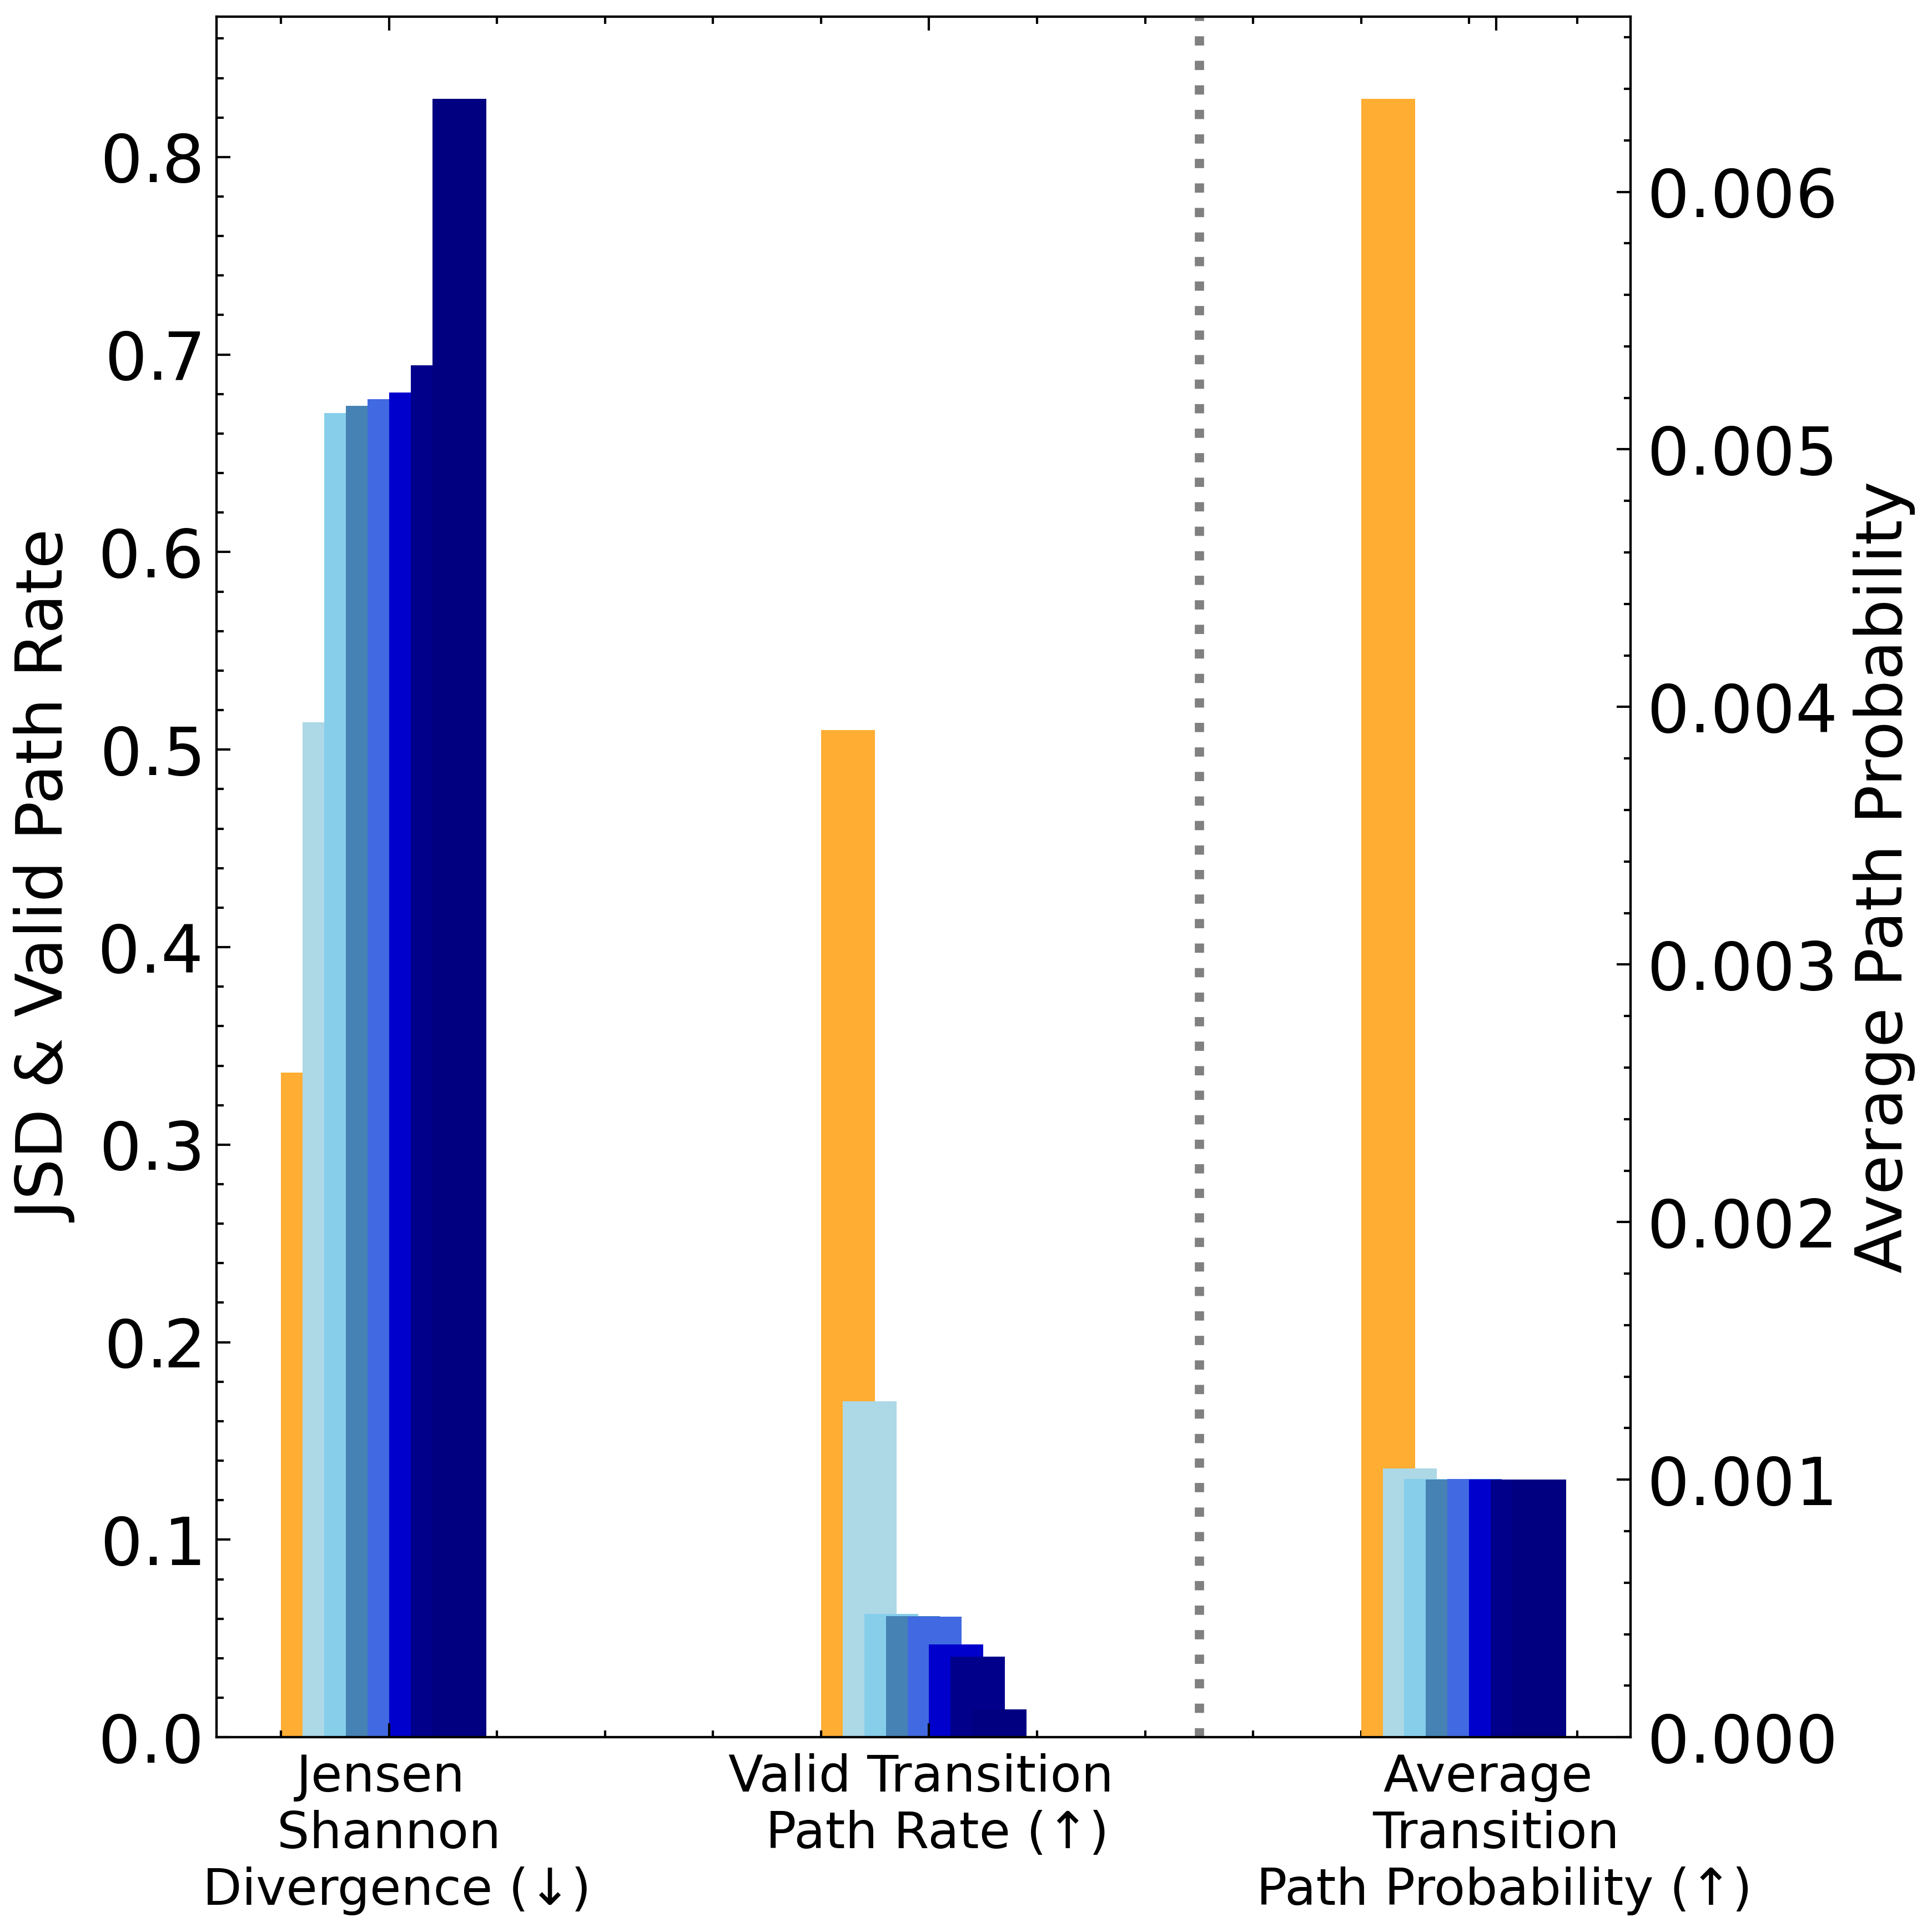

<Figure size 1800x2400 with 0 Axes>

In [11]:
proteins = ["trp_cage", "chignolin", "bba", "villin", "protein_g"]
results_dir = 'saved_models'
figure_name = "fastfolder_msm_figure"
make_fastfolder_msm_figures(proteins, results_dir, figure_name, errorbar=False)

['OM Interpolation - Flow Matching Model', 'OM Interpolation - Diffusion Model', '1ns', '2ns', '4ns', '6ns', '8ns', '10ns', '12ns']


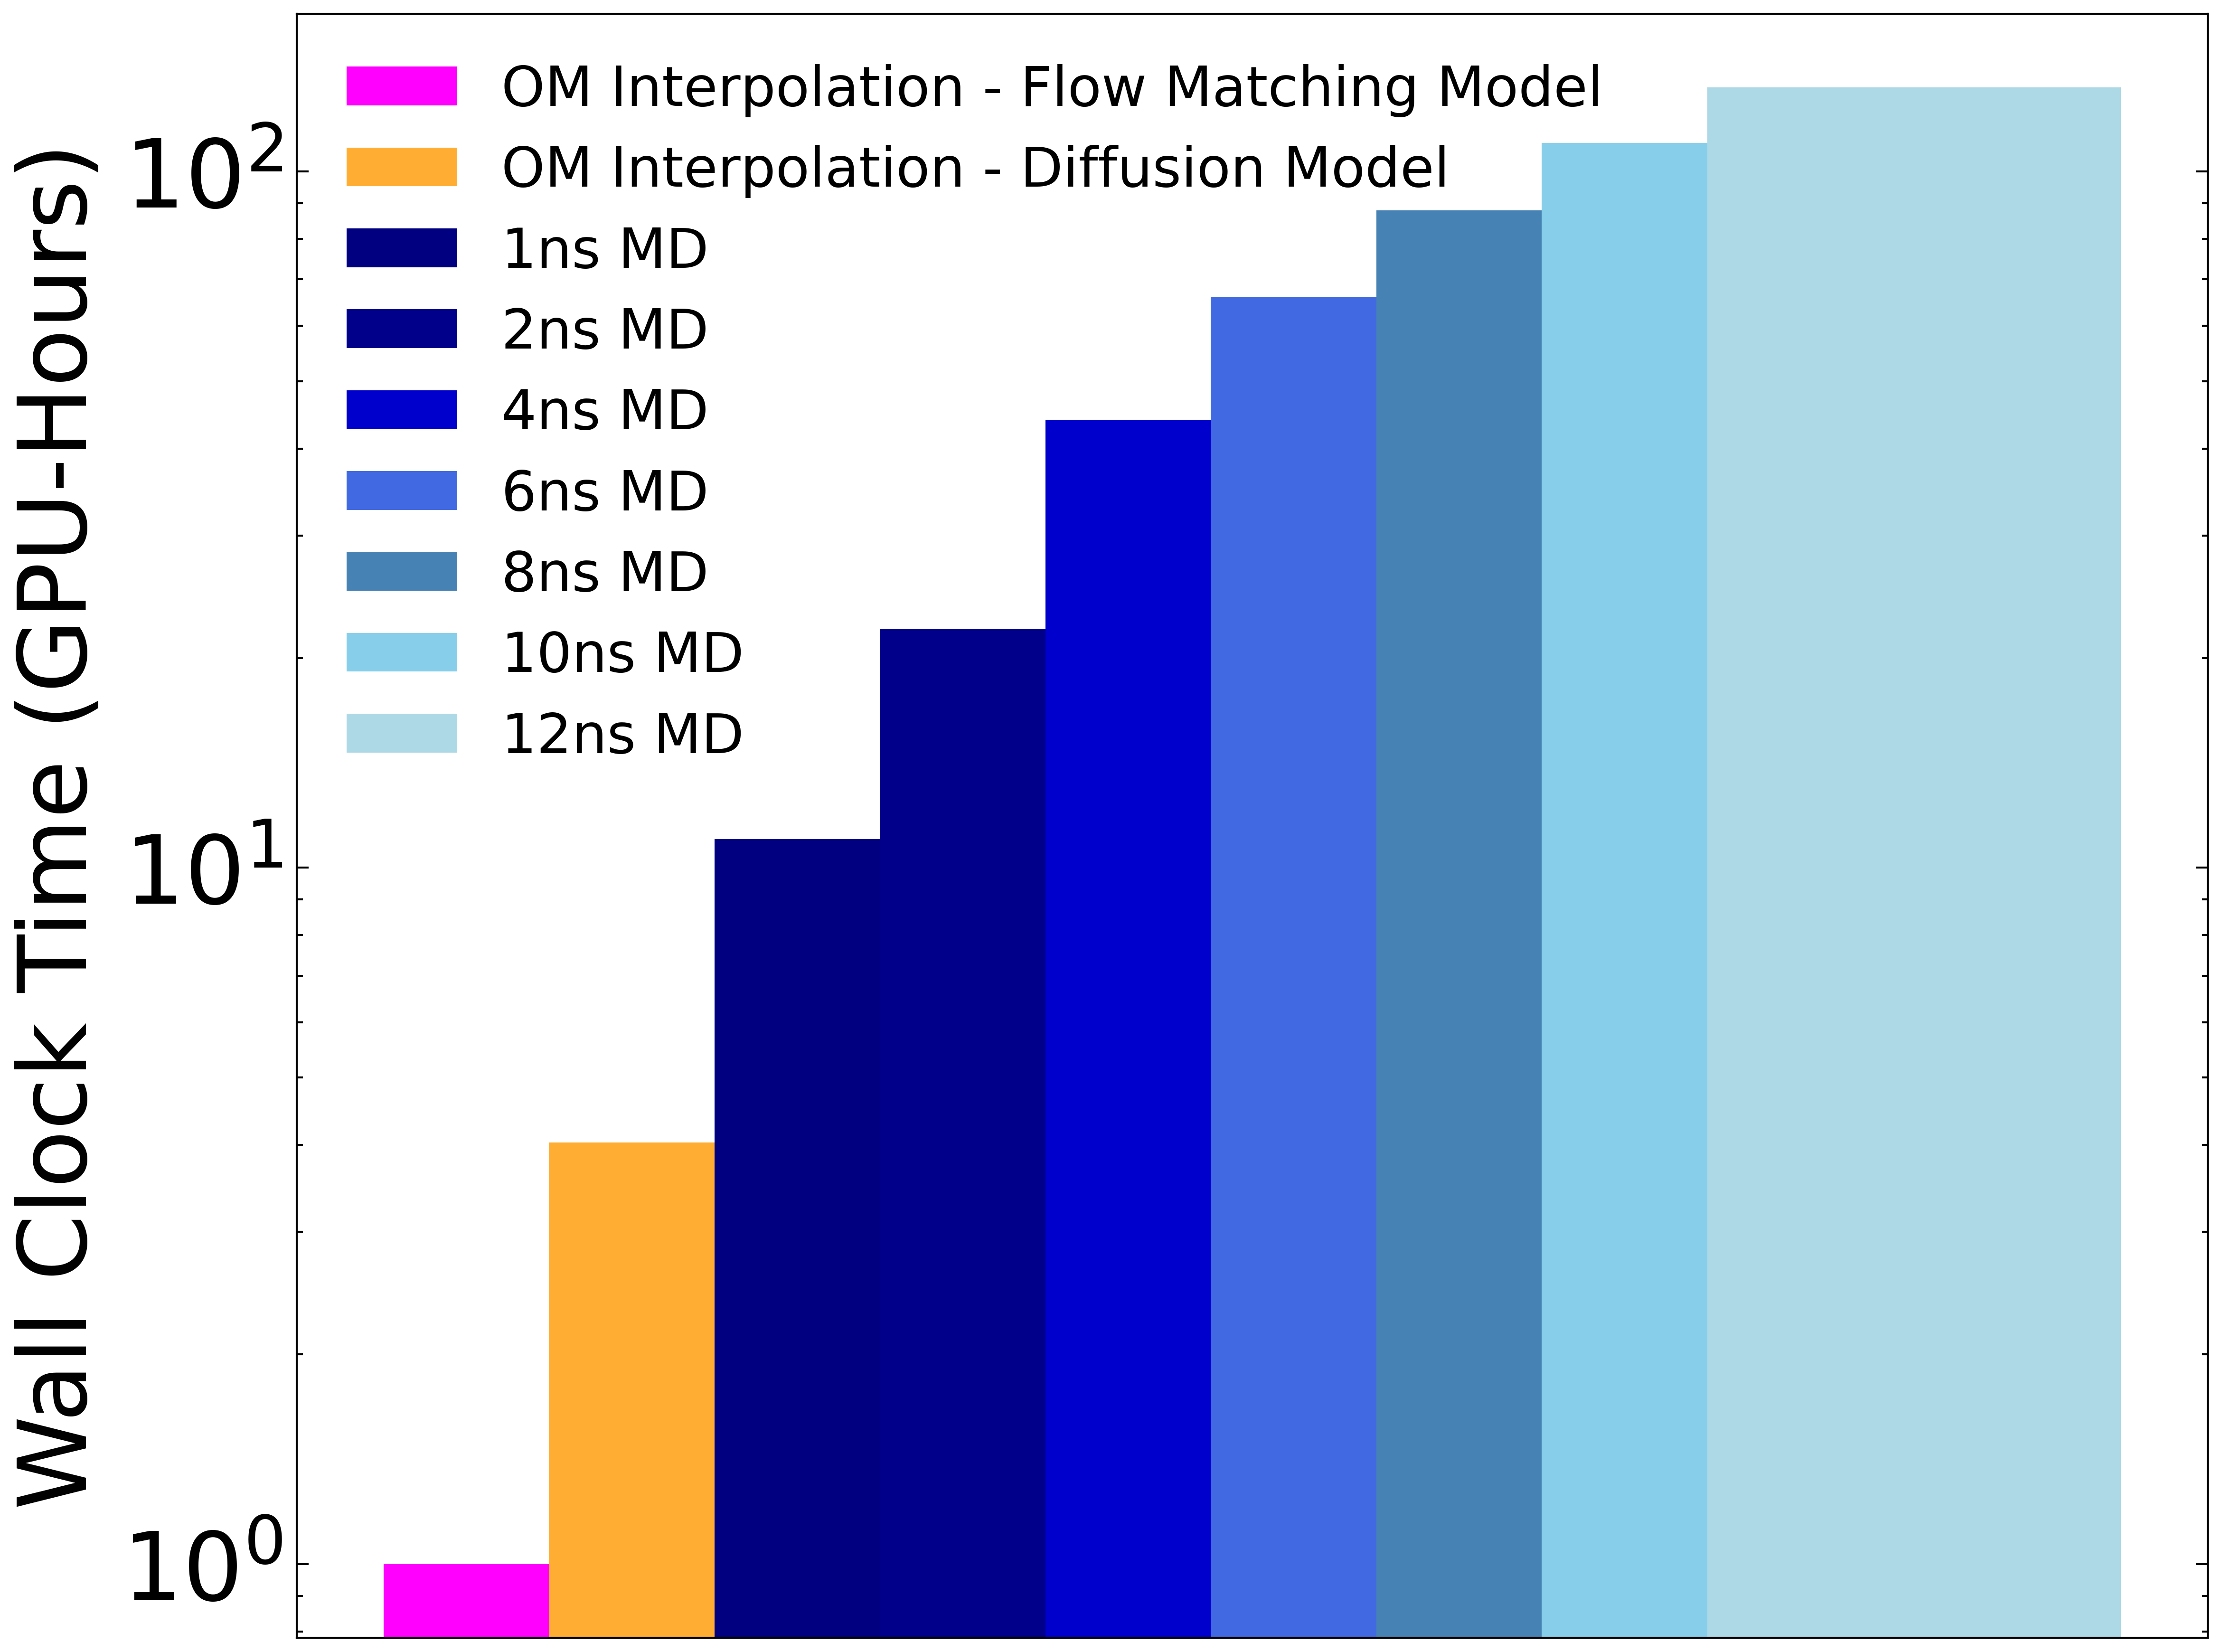

In [13]:
# Make a plot of wall clock time for BBA
# Define colors
colors = {
    "12ns": "#ADD8E6",  # Light blue
    "10ns": "#87CEEB",  # Sky blue
    "8ns": "#4682B4",  # Steel blue
    "6ns": "#4169E1",  # Royal blue
    "4ns": "#0000CD",  # Medium blue
    "2ns": "#00008B",   # Dark blue
    "1ns": "#000080"    # Navy blue
}

other_colors = [MAGENTA, ORANGE, SILVER, RPURPLE, GREEN, DARK_GRAY]

# Data (need to replace with actual values)

bba_diffusion_time = 242 / 60 # (242 minutes to generate 32 paths)
bba_flowmatching_time = 60 / 60 # (60 minutes to generate 32 paths) # TODO: replace with actual value
bba_langevin_rep_times = [1, 2, 4, 6, 8, 10, 12]
# Langevin: 11,000 seconds per ns
bba_langevin_rep_times = [(time * 11,000 / 3600) for time in bba_langevin_rep_times]

times =  [bba_flowmatching_time, bba_diffusion_time] + bba_langevin_rep_times
methods = ["OM Interpolation - Flow Matching Model", "OM Interpolation - Diffusion Model"] + ["1ns", "2ns", "4ns", "6ns", "8ns", "10ns", "12ns"]

# make a bar plot of the same style as the other figures

# Set up bar positions
bar_width = 0.01
n_metrics = 1
n_methods = 9 # 7 replicates + 2 methods
x = np.arange(n_metrics)

# Initialize figure and axes
plt.figure(figsize=(8, 6))

print(methods)
for i, (method, time) in enumerate(zip(methods, times)):
    if method in colors.keys():
        color = colors[method]
    else:
        color = other_colors.pop(0)
    
    #Plot wall clock time
    plt.bar(i * bar_width * 0.4, time, bar_width, label=method + " MD" if "ns" in method else method, color=color)
plt.yscale("log")


# Customize axes
# ax1.set_xlabel("Metrics", fontsize=12)
plt.ylabel("Wall Clock Time (GPU-Hours)", fontsize=24)
# make y-ticks larger
plt.yticks(fontsize=24)
# no x labels
plt.xticks([])
plt.legend(fontsize=14, loc="upper left")
# ax1.set_xticks(x + (n_methods - 1) * bar_width / 2)
# custom_positions = [0.15, 1.15, 2.1]  # Centered positions for 'JSD', 'Valid Path Rate', 'Average Path Probability'
# ax1.set_xticks(custom_positions)
# ax1.set_xticklabels(metrics, fontsize=11)

# Title and layout
# plt.title("Performance Comparison of Methods by Metrics", fontsize=14)
plt.tight_layout()
plt.savefig("fastfolders_time.png")
plt.show()


In [7]:
# import os
# import glob
# # list all files with *pkl extension
# directory = "/data/sanjeevr/om_results_backup/main_eval_output_om_interpolate_initial_guess_level=100"
# files = glob.glob(os.path.join(directory, "*.pkl"))
# print([os.path.basename(f) for f in files])

['AVGR_metadata.pkl', 'AVGR.pkl', 'HYPI_metadata.pkl', 'PQYL_metadata.pkl', 'PQYL.pkl', 'GNIA_metadata.pkl', 'GNIA.pkl', 'LWQD_metadata.pkl', 'LWQD.pkl', 'SHSC_metadata.pkl', 'SHSC.pkl', 'FNCR_metadata.pkl', 'FNCR.pkl', 'VAGR_metadata.pkl', 'VAGR.pkl', 'YNLS_metadata.pkl', 'YNLS.pkl', 'NSLF_metadata.pkl', 'NSLF.pkl', 'MIIM_metadata.pkl', 'MIIM.pkl', 'RYPG_metadata.pkl', 'RYPG.pkl', 'DCQI_metadata.pkl', 'DCQI.pkl', 'PMFI_metadata.pkl', 'PMFI.pkl', 'CIFL_metadata.pkl', 'CIFL.pkl', 'TIRG_metadata.pkl', 'TIRG.pkl', 'CRVF_metadata.pkl', 'CRVF.pkl', 'WHEL_metadata.pkl', 'WHEL.pkl', 'ALWP_metadata.pkl', 'ALWP.pkl', 'CMKC_metadata.pkl', 'CMKC.pkl', 'PWID_metadata.pkl', 'PWID.pkl', 'ESTM_metadata.pkl', 'ESTM.pkl', 'EHDY_metadata.pkl', 'EHDY.pkl', 'EMIR_metadata.pkl', 'EMIR.pkl', 'NAWM_metadata.pkl', 'NAWM.pkl', 'LNCW_metadata.pkl', 'LNCW.pkl', 'FYDK_metadata.pkl', 'FYDK.pkl', 'WKEG_metadata.pkl', 'WKEG.pkl', 'HHCG_metadata.pkl', 'HHCG.pkl', 'NKPS_metadata.pkl', 'NKPS.pkl', 'FCDI_metadata.pkl', 